## Total Daily Precipation - Jan/2025

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr

DAILY = Path("/media/mary-camila/Expansion/era5land/processed_daily")
FIGURES = Path("../figures")
FIGURES.mkdir(exist_ok=True)
ANO, MES = 2025, 1
GRUPOS = ["tp", "pev", "ssrd", "temp", "wind"]

ds = xr.merge([
    xr.open_dataset(DAILY / g / f"{g}_{ANO}_{MES:02d}.nc")
    for g in GRUPOS
])

print(ds.sizes)          # valid_time: 31, latitude: 411, longitude: 451
print(list(ds.data_vars))
ds


Frozen({'valid_time': 31, 'latitude': 411, 'longitude': 451})
['tp', 'pev', 'ssrd', 't2m', 'd2m', 't2m_min', 't2m_max', 'u10', 'v10']


<xarray.Dataset> Size: 207MB
Dimensions:     (valid_time: 31, latitude: 411, longitude: 451)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 248B 2025-01-01 ... 2025-01-31
  * latitude    (latitude) float64 3kB 6.0 5.9 5.8 5.7 ... -34.8 -34.9 -35.0
  * longitude   (longitude) float64 4kB -75.0 -74.9 -74.8 ... -30.2 -30.1 -30.0
Data variables:
    tp          (valid_time, latitude, longitude) float32 23MB ...
    pev         (valid_time, latitude, longitude) float32 23MB ...
    ssrd        (valid_time, latitude, longitude) float32 23MB ...
    t2m         (valid_time, latitude, longitude) float32 23MB ...
    d2m         (valid_time, latitude, longitude) float32 23MB ...
    t2m_min     (valid_time, latitude, longitude) float32 23MB ...
    t2m_max     (valid_time, latitude, longitude) float32 23MB ...
    u10         (valid_time, latitude, longitude) float32 23MB ...
    v10         (valid_time, latitude, longitude) float32 23MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-08-12T16:18 GRIB to CDM+CF via cfgrib-0.9.1...

In [2]:
conv = xr.Dataset({
    "tp_mm":     ds.tp * 1000,            # m -> mm/dia
    "pev_mm":    -ds.pev * 1000,          # negado: demanda positiva, mm/dia
    "ssrd_wm2":  ds.ssrd / 86400,         # J/m2/dia -> W/m2
    "t2m_c":     ds.t2m - 273.15,         # K -> °C
    "d2m_c":     ds.d2m - 273.15,
    "t2m_min_c": ds.t2m_min - 273.15,
    "t2m_max_c": ds.t2m_max - 273.15,
    "u10":       ds.u10,                  # m/s
    "v10":       ds.v10,
    "vento_ms":  np.sqrt(ds.u10**2 + ds.v10**2),
    "dpd_c":     ds.t2m - ds.d2m,         # depressão do ponto de orvalho
})

desc = pd.DataFrame({
    nome: pd.Series(da.values.ravel()).describe()
    for nome, da in conv.data_vars.items()
}).T
desc.round(2)


,count,mean,std,min,25%,50%,75%,max
tp_mm,3704593.0,6.32,9.52,0.00,0.29,2.67,9.16,357.78
pev_mm,3704593.0,11.09,7.73,-20.40,6.15,8.88,13.54,77.45
ssrd_wm2,3704593.0,236.96,76.30,16.12,183.50,240.27,290.72,437.47
t2m_c,3704593.0,24.42,4.90,-7.20,23.81,25.40,26.81,36.46
d2m_c,3704593.0,19.24,5.95,-29.01,18.07,21.34,22.94,26.11
t2m_min_c,3704593.0,20.86,5.06,-17.30,20.61,22.37,23.36,30.54
t2m_max_c,3704593.0,28.99,5.15,-3.23,27.46,29.75,31.75,45.69
u10,3704593.0,-0.41,1.12,-8.86,-0.98,-0.31,0.25,7.57
v10,3704593.0,-0.38,1.05,-7.64,-0.98,-0.41,0.13,8.39
vento_ms,3704593.0,1.34,0.93,0.00,0.65,1.14,1.79,10.10


In [3]:
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
from matplotlib.animation import FuncAnimation, PillowWriter

tp = (ds.tp * 1000).load()          # mm/dia, ~23 MB na memória
lon, lat = tp.longitude.values, tp.latitude.values
extent = [lon.min(), lon.max(), lat.min(), lat.max()]

# escala fixa e não linear: precipitação tem cauda longa
niveis = [0, 1, 2, 5, 10, 20, 30, 50, 75, 100, 150]
cmap = plt.get_cmap("YlGnBu", len(niveis) - 1)
cmap.set_bad("white")               # oceano (NaN)
norm = BoundaryNorm(niveis, cmap.N)

fig, ax = plt.subplots(figsize=(6, 5.5), dpi=110)
im = ax.imshow(tp.isel(valid_time=0), extent=extent, origin="upper",
               cmap=cmap, norm=norm, interpolation="nearest")
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
fig.colorbar(im, ax=ax, extend="max", label="precipitação (mm/dia)")
titulo = ax.set_title("")
fig.tight_layout()

def frame(i):
    im.set_data(tp.isel(valid_time=i))
    titulo.set_text(f"ERA5-Land — {str(tp.valid_time[i].values)[:10]}")
    return im, titulo

ani = FuncAnimation(fig, frame, frames=tp.sizes["valid_time"], blit=False)
ani.save(FIGURES / f"precipitation_daily_{ANO}_{MES:02d}.gif", writer=PillowWriter(fps=4))
plt.close(fig)


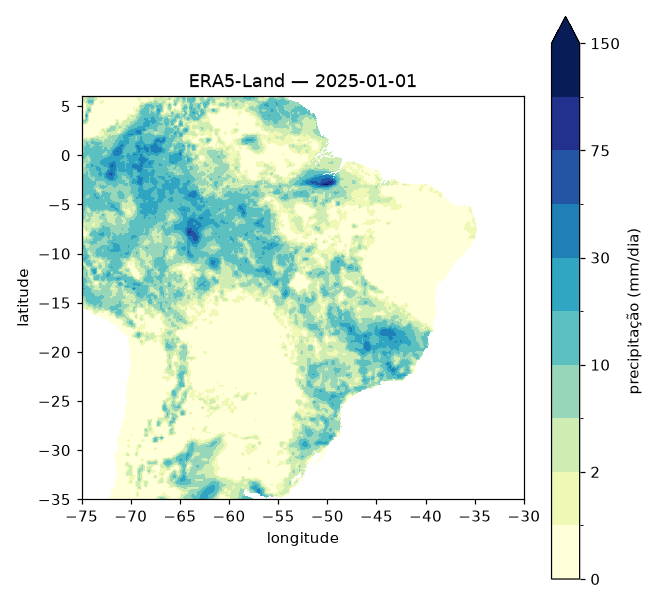

In [4]:
from IPython.display import Image
Image(filename=str(FIGURES / f"precipitation_daily_{ANO}_{MES:02d}.gif"))


## Total Weekly Precipation - Jan/2025

In [5]:
WEEKLY = Path("/media/mary-camila/Expansion/era5land/processed_weekly")
ANO = 2025
GRUPOS = ["tp", "pev", "ssrd", "temp", "wind"]

ds = xr.merge([
    xr.open_dataset(WEEKLY / g / f"{g}_{ANO}.nc")
    for g in GRUPOS
])

print(ds.sizes)                       # valid_time: 51 (2025 perde a última semana)
print(ds.valid_time.to_index()[:3])   # todas em segunda-feira
ds

Frozen({'valid_time': 51, 'latitude': 411, 'longitude': 451})
DatetimeIndex(['2025-01-06', '2025-01-13', '2025-01-20'], dtype='datetime64[ns]', name='valid_time', freq=None)


<xarray.Dataset> Size: 340MB
Dimensions:     (valid_time: 51, latitude: 411, longitude: 451)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 408B 2025-01-06 ... 2025-12-22
  * latitude    (latitude) float64 3kB 6.0 5.9 5.8 5.7 ... -34.8 -34.9 -35.0
  * longitude   (longitude) float64 4kB -75.0 -74.9 -74.8 ... -30.2 -30.1 -30.0
Data variables:
    tp          (valid_time, latitude, longitude) float32 38MB ...
    pev         (valid_time, latitude, longitude) float32 38MB ...
    ssrd        (valid_time, latitude, longitude) float32 38MB ...
    t2m         (valid_time, latitude, longitude) float32 38MB ...
    d2m         (valid_time, latitude, longitude) float32 38MB ...
    t2m_min     (valid_time, latitude, longitude) float32 38MB ...
    t2m_max     (valid_time, latitude, longitude) float32 38MB ...
    u10         (valid_time, latitude, longitude) float32 38MB ...
    v10         (valid_time, latitude, longitude) float32 38MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-08-12T16:18 GRIB to CDM+CF via cfgrib-0.9.1...

In [6]:
conv = xr.Dataset({
    "tp_mm":     ds.tp * 1000,          # mm/semana
    "pev_mm":    -ds.pev * 1000,        # mm/semana, demanda positiva
    "ssrd_wm2":  ds.ssrd / 604800,      # J/m2/semana -> W/m2
    "t2m_c":     ds.t2m - 273.15,
    "d2m_c":     ds.d2m - 273.15,
    "t2m_min_c": ds.t2m_min - 273.15,   # mínima da semana
    "t2m_max_c": ds.t2m_max - 273.15,   # máxima da semana
    "u10":       ds.u10,
    "v10":       ds.v10,
    "vento_ms":  np.sqrt(ds.u10**2 + ds.v10**2),
    "dpd_c":     ds.t2m - ds.d2m,
})

desc = pd.DataFrame({
    nome: pd.Series(da.values.ravel()).describe()
    for nome, da in conv.data_vars.items()
}).T
desc.round(2)


,count,mean,std,min,25%,50%,75%,max
tp_mm,6094653.0,30.37,36.19,0.00,2.28,17.40,47.29,721.53
pev_mm,6094653.0,80.23,57.00,-3.55,43.86,65.54,94.18,544.26
ssrd_wm2,6094653.0,216.40,53.92,25.92,180.47,214.23,248.01,432.31
t2m_c,6094653.0,22.91,6.13,-21.65,21.43,25.06,26.47,35.90
d2m_c,6094653.0,16.57,8.56,-38.65,13.34,19.31,22.64,25.27
t2m_min_c,6094653.0,17.27,7.40,-34.53,14.52,20.53,22.29,28.75
t2m_max_c,6094653.0,30.01,5.79,-13.54,28.78,31.26,33.21,51.26
u10,6094653.0,-0.69,1.02,-8.88,-1.21,-0.54,-0.08,7.10
v10,6094653.0,-0.10,0.87,-7.69,-0.57,-0.13,0.29,7.18
vento_ms,6094653.0,1.20,0.92,0.00,0.51,0.98,1.63,9.49


In [ ]:
tp = (ds.tp * 1000).load()          # mm/semana
lon, lat = tp.longitude.values, tp.latitude.values
extent = [lon.min(), lon.max(), lat.min(), lat.max()]

# níveis ~5x maiores que no diário, porque agora é total de 7 dias
niveis = [0, 5, 10, 25, 50, 75, 100, 150, 200, 300, 500]
cmap = plt.get_cmap("YlGnBu", len(niveis) - 1)
cmap.set_bad("white")
norm = BoundaryNorm(niveis, cmap.N)

fig, ax = plt.subplots(figsize=(6, 5.5), dpi=110)
im = ax.imshow(tp.isel(valid_time=0), extent=extent, origin="upper",
               cmap=cmap, norm=norm, interpolation="nearest")
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
fig.colorbar(im, ax=ax, extend="max", label="precipitação (mm/semana)")
titulo = ax.set_title("")
fig.tight_layout()

def frame(i):
    seg = pd.Timestamp(tp.valid_time[i].values)
    im.set_data(tp.isel(valid_time=i))
    titulo.set_text(f"ERA5-Land — semana {seg.date()} a {(seg + pd.Timedelta(days=6)).date()}")
    return im, titulo

ani = FuncAnimation(fig, frame, frames=tp.sizes["valid_time"], blit=False)
ani.save(FIGURES / f"precipitation_weekly_{ANO}.gif", writer=PillowWriter(fps=3))
plt.close(fig)


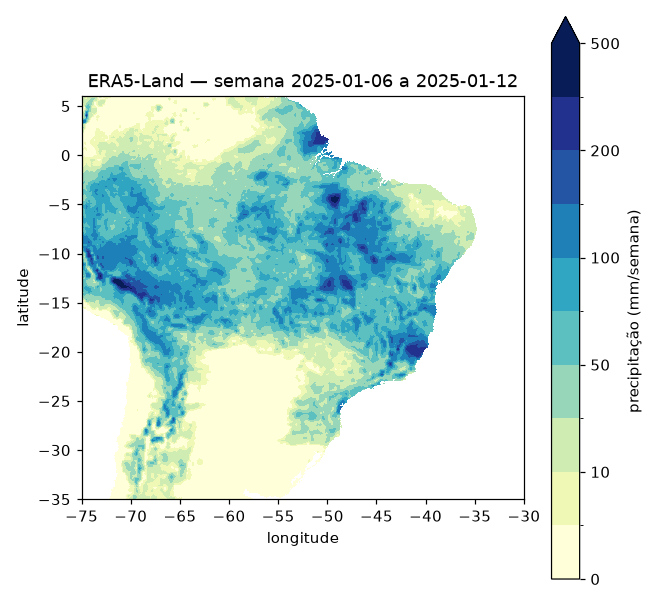

In [ ]:
Image(filename=str(FIGURES / f"precipitation_weekly_{ANO}.gif"))
